# **RQ2**: Dynamic Community Detection

In [3]:
import os
import igraph as ig
import leidenalg

In [45]:
# --- FASE 1: Core temporale ---
all_sets = []

for i in range(1, 8):
    path = os.path.join(
        'networks_hybrid_annotated',
        f'graph_snap{i}_hybrid.igp'
    )
    g = ig.Graph.Read_Pickle(path)
    all_sets.append(set(g.vs['token']))

core_tokens = set.intersection(*all_sets)
print(f"Dimensioni del Core temporale: {len(core_tokens)} nodi")

# --- FASE 2: Filtro + Giant Component ---
os.makedirs('networks_core', exist_ok=True)

for i in range(1, 8):
    print(f"\nProcessing snapshot {i}")
    
    input_path = os.path.join(
        'networks_hybrid_annotated',
        f'graph_snap{i}_hybrid.igp'
    )
    g = ig.Graph.Read_Pickle(input_path)

    # STEP 1 — filtro sui token del core
    g_core = g.subgraph(g.vs.select(token_in=core_tokens))

    # STEP 2 — tieni solo la componente più grande
    comps = g_core.components(mode='weak') if g_core.is_directed() else g_core.components()
    g_final = comps.giant()

    print(f"Nodes after core filter: {g_core.vcount()}")
    print(f"Nodes in largest component: {g_final.vcount()}")

    # Salvataggio
    output_path = os.path.join(
        'networks_core',
        f'graph_snap{i}.igp'
    )
    g_final.write_pickle(output_path)

print("\nCore + Largest Component networks saved correctly.")

Dimensioni del Core temporale: 20113 nodi

Processing snapshot 1
Nodes after core filter: 20113
Nodes in largest component: 20066

Processing snapshot 2
Nodes after core filter: 20113
Nodes in largest component: 20088

Processing snapshot 3
Nodes after core filter: 20113
Nodes in largest component: 20072

Processing snapshot 4
Nodes after core filter: 20113
Nodes in largest component: 20085

Processing snapshot 5
Nodes after core filter: 20113
Nodes in largest component: 20076

Processing snapshot 6
Nodes after core filter: 20113
Nodes in largest component: 20064

Processing snapshot 7
Nodes after core filter: 20113
Nodes in largest component: 20066

Core + Largest Component networks saved correctly.


In [46]:
import os
import igraph as ig

for i in range(1, 8):
    print(f'\nAnalyzing graph of snapshot {i}')
    
    file = os.path.join('networks_core', f'graph_snap{i}.igp')
    g = ig.Graph.Read_Pickle(file)
    
    # Use 'weak' if directed, otherwise default is fine
    comps = g.components(mode='weak') if g.is_directed() else g.components()
    
    sizes = comps.sizes()
    sizes_sorted = sorted(sizes, reverse=True)
    
    print(f'Number of connected components: {len(sizes)}')
    print(f'Top 5 component sizes: {sizes_sorted[:5]}')


Analyzing graph of snapshot 1
Number of connected components: 1
Top 5 component sizes: [20066]

Analyzing graph of snapshot 2
Number of connected components: 1
Top 5 component sizes: [20088]

Analyzing graph of snapshot 3
Number of connected components: 1
Top 5 component sizes: [20072]

Analyzing graph of snapshot 4
Number of connected components: 1
Top 5 component sizes: [20085]

Analyzing graph of snapshot 5
Number of connected components: 1
Top 5 component sizes: [20076]

Analyzing graph of snapshot 6
Number of connected components: 1
Top 5 component sizes: [20064]

Analyzing graph of snapshot 7
Number of connected components: 1
Top 5 component sizes: [20066]


In [47]:
import json

for i in range(1, 8):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('networks_core', f'graph_snap{i}.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights='weight',
        resolution_parameter=1.0
    )
    print(f'\tCorrectly ran Leiden CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Leiden CD
	#comms: 10
		4470
		3667
		3124
		1887
		1604
		1498
		1218
		1053
		970
		575

Analyzing graph of snapshot 2
	Correctly ran Leiden CD
	#comms: 12
		3703
		3164
		2877
		2412
		2035
		1835
		936
		871
		847
		736
		578
		94

Analyzing graph of snapshot 3
	Correctly ran Leiden CD
	#comms: 10
		4383
		3466
		2779
		2134
		2054
		1984
		980
		963
		923
		406

Analyzing graph of snapshot 4
	Correctly ran Leiden CD
	#comms: 13
		3454
		3345
		2105
		2055
		2035
		1957
		1937
		1049
		1012
		475
		445
		126
		90

Analyzing graph of snapshot 5
	Correctly ran Leiden CD
	#comms: 12
		3267
		2973
		2480
		2240
		2178
		2078
		1880
		936
		736
		651
		515
		142

Analyzing graph of snapshot 6
	Correctly ran Leiden CD
	#comms: 12
		3120
		2768
		2543
		2484
		2406
		1832
		1675
		1041
		965
		634
		434
		162

Analyzing graph of snapshot 7
	Correctly ran Leiden CD
	#comms: 12
		3448
		3164
		2535
		2519
		2234
		1900
		1683
		943
		604
		553
	

In [48]:
import json

for i in range(1, 8):
    print(f'\nAnalyzing graph of snapshot {i}')
    file = os.path.join('networks_core', f'graph_snap{i}.igp')
    g = ig.Graph.Read_Pickle(file)
    
    partition = g.community_infomap(
        edge_weights='weight'
    )

    print(f'\tCorrectly ran Infomap CD')
    
    print(f'\t#comms: {len(partition)}')

    communities = list()
    
    for j, com in enumerate(partition):
        # print(f'\t\t{len(com)}')
        communities.append(list())
        for node in com:
            communities[j].append(g.vs[node]['token'])

    out = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    with open(out, 'w', encoding='utf-8') as f:
        json.dump(communities, f)


Analyzing graph of snapshot 1
	Correctly ran Infomap CD
	#comms: 212

Analyzing graph of snapshot 2
	Correctly ran Infomap CD
	#comms: 131

Analyzing graph of snapshot 3
	Correctly ran Infomap CD
	#comms: 136

Analyzing graph of snapshot 4
	Correctly ran Infomap CD
	#comms: 110

Analyzing graph of snapshot 5
	Correctly ran Infomap CD
	#comms: 114

Analyzing graph of snapshot 6
	Correctly ran Infomap CD
	#comms: 136

Analyzing graph of snapshot 7
	Correctly ran Infomap CD
	#comms: 137


## Leiden communities comparison by snapshots

In [4]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import numpy as np

In [5]:
def overlap_coeff(com1: list, com2: list) -> float:
    """
    Calculate Overlap Coefficient between two communities.
        
    ---
    
    Args:
        com1 (list): First community
        com2 (list): Second community
    
    Returns:
        float: Float representing the Overlap Coefficient
    """
    set1, set2 = set(com1), set(com2)
    return len(set1 & set2) / min(len(set1), len(set2))


def directional_overlap(com_prev: list, com_next: list) -> float:
    """
    Directional overlap from previous snapshot to next snapshot.
    Penalizes small → large, rewards large → small.
    """
    set_prev, set_next = set(com_prev), set(com_next)
    inter = len(set_prev & set_next)

    if inter == 0:
        return 0.0

    return inter / len(set_next)


def compare_partitions(part_prev: list, part_cur: str) -> list:
    """
    Compare two partitions (lists of communities) from consecutive snapshots by computing
    the Jaccard similarity between each pair of communities.

    Args:
        snap_prev (str): Path to the JSON file containing the previous snapshot's partition.
        snap_cur (str): Path to the JSON file containing the current snapshot's partition.

    Returns:
        list: A matrix (list of lists) where each element [i][j] is the Overlap Coefficient
              between the i-th community in the current snapshot and the j-th community in the previous snapshot.
    """
    sim_matrix = np.zeros((len(part_cur), len(part_prev)))
    for i, com_cur in enumerate(part_cur):
        for j, com_prev in enumerate(part_prev):
            sim = directional_overlap(com_prev, com_cur)
            sim_matrix[i][j] = sim
            
    return sim_matrix

In [6]:
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D


# --------------------------------------------------
# Graph construction
# --------------------------------------------------
def build_temporal_graph(sim_matrices, community_sizes, threshold):
    G = nx.DiGraph()

    for t, sim in enumerate(sim_matrices):
        n_curr, n_prev = sim.shape

        for i in range(n_prev):
            if community_sizes[t][i] > 50:
                G.add_node((t, i), snapshot=t, size=community_sizes[t][i])

        for j in range(n_curr):
            if community_sizes[t + 1][j] > 50:
                G.add_node((t + 1, j), snapshot=t + 1, size=community_sizes[t + 1][j])

        for i in range(n_prev):
            for j in range(n_curr):
                w = sim[j, i]
                if (
                    w >= threshold
                    and community_sizes[t][i] > 50
                    and community_sizes[t + 1][j] > 50
                ):
                    G.add_edge(
                        (t, i),
                        (t + 1, j),
                        weight=w,
                        label=f"{w:.2f}",
                    )

    return G


# --------------------------------------------------
# Layered layout
# --------------------------------------------------
def compute_layered_layout(G, x_spacing, y_spacing):
    pos = {}
    layers = {}

    for n in G.nodes():
        snapshot = G.nodes[n].get("snapshot", None)
        if snapshot is None:
            raise ValueError(f"Node {n} has no snapshot attribute")
        layers.setdefault(snapshot, []).append(n)

    for t in sorted(layers):
        for idx, n in enumerate(sorted(layers[t])):
            pos[n] = (t * x_spacing, -idx * y_spacing)

    return pos


# --------------------------------------------------
# Stats and node coloring
# --------------------------------------------------
def compute_stats_and_colors(G, community_sizes, last_snapshot):
    stats = defaultdict(
        lambda: {
            "total": -1,
            "total_over": 0,
            "internal": 0,
            "births": 0,
            "deaths": 0,
            "isolated": 0,
            "merges": 0,
            "splits": 0,
        }
    )

    node_colors = []

    for n in G.nodes():
        snap = n[0]

        if stats[snap]["total"] == -1:
            stats[snap]["total"] = len(community_sizes[snap])

        stats[snap]["total_over"] += 1

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)

        if outdeg > 1:
            stats[snap]['splits'] += 1

        if indeg > 1:
            stats[snap]['merges'] += 1

        # boundary snapshots
        if snap == 0 and outdeg > 0:
            node_colors.append("black")
            stats[snap]["internal"] += 1
            continue

        if snap == last_snapshot and indeg > 0:
            node_colors.append("black")
            stats[snap]["internal"] += 1
            continue

        if indeg == 0 and outdeg > 0:
            node_colors.append("green")
            stats[snap]["births"] += 1

        elif indeg > 0 and outdeg == 0:
            node_colors.append("red")
            stats[snap]["deaths"] += 1

        elif indeg == 0 and outdeg == 0:
            node_colors.append("purple")
            stats[snap]["isolated"] += 1

        else:
            node_colors.append("black")
            stats[snap]["internal"] += 1

    return stats, node_colors


def print_stats(stats):
    print("\nSnapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits")
    print("-" * 85)

    for snap in sorted(stats):
        s = stats[snap]
        print(
            f"{snap:8} | {s['total']:5} | {s['total_over']:8} | "
            f"{s['internal']:8} | {s['births']:6} | "
            f"{s['deaths']:6} | {s['isolated']:8} | "
            f"{s['merges']:6} | {s['splits']:6}"
        )


# --------------------------------------------------
# Drawing helpers
# --------------------------------------------------
def draw_nodes(G, pos, node_colors, node_size):
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=node_colors,
        alpha=0.8,
    )


def draw_node_labels(G, pos):
    node_labels = {n: str(G.nodes[n]["size"]) for n in G.nodes()}

    label_pos = {
        n: (pos[n][0], pos[n][1] + 0.3)
        for n in pos
    }

    nx.draw_networkx_labels(
        G,
        label_pos,
        labels=node_labels,
        font_size=8,
    )


def draw_edges(G, pos, ax):
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    norm = mcolors.Normalize(vmin=min(weights), vmax=max(weights))
    cmap = cm.plasma

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=weights,
        edge_cmap=cmap,
        edge_vmin=norm.vmin,
        edge_vmax=norm.vmax,
        alpha=0.6,
    )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Community directional overlap coefficient")


def draw_legend():
    legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               label="Birth", markerfacecolor="green", markersize=10),
        Line2D([0], [0], marker="o", color="w",
               label="Death", markerfacecolor="red", markersize=10),
        Line2D([0], [0], marker="o", color="w",
               label="Isolated", markerfacecolor="purple", markersize=10),
    ]

    plt.legend(
        handles=legend_elements,
        loc="lower right",
        frameon=False,
    )


# --------------------------------------------------
# Main plotting function
# --------------------------------------------------
def plot_temporal_community_similarity(
    sim_matrices,
    community_sizes,
    threshold=0.5,
    x_spacing=3.0,
    y_spacing=1.0,
    node_size=50,
    clustering="Leiden",
):
    G = build_temporal_graph(sim_matrices, community_sizes, threshold)
    pos = compute_layered_layout(G, x_spacing, y_spacing)

    _, ax = plt.subplots(figsize=(14, 8))

    stats, node_colors = compute_stats_and_colors(
        G,
        community_sizes,
        last_snapshot=max(G.nodes())[0],
    )

    print_stats(stats)

    draw_nodes(G, pos, node_colors, node_size)
    draw_node_labels(G, pos)
    draw_edges(G, pos, ax)
    draw_legend()

    plt.title(
        f"Evolution of {clustering}-detected communities",
        fontsize=20,
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [7]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 8):
    file = os.path.join('leiden_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)


Snapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits
-------------------------------------------------------------------------------------
       0 |    10 |       10 |       10 |      0 |      0 |        0 |      0 |      1
       1 |    12 |       12 |        8 |      1 |      3 |        0 |      0 |      1
       2 |    10 |       10 |        9 |      0 |      1 |        0 |      0 |      3
       3 |    13 |       13 |       12 |      0 |      1 |        0 |      0 |      0
       4 |    12 |       12 |       12 |      0 |      0 |        0 |      0 |      0
       5 |    12 |       12 |       11 |      0 |      1 |        0 |      0 |      1
       6 |    12 |       12 |       12 |      0 |      0 |        0 |      0 |      0


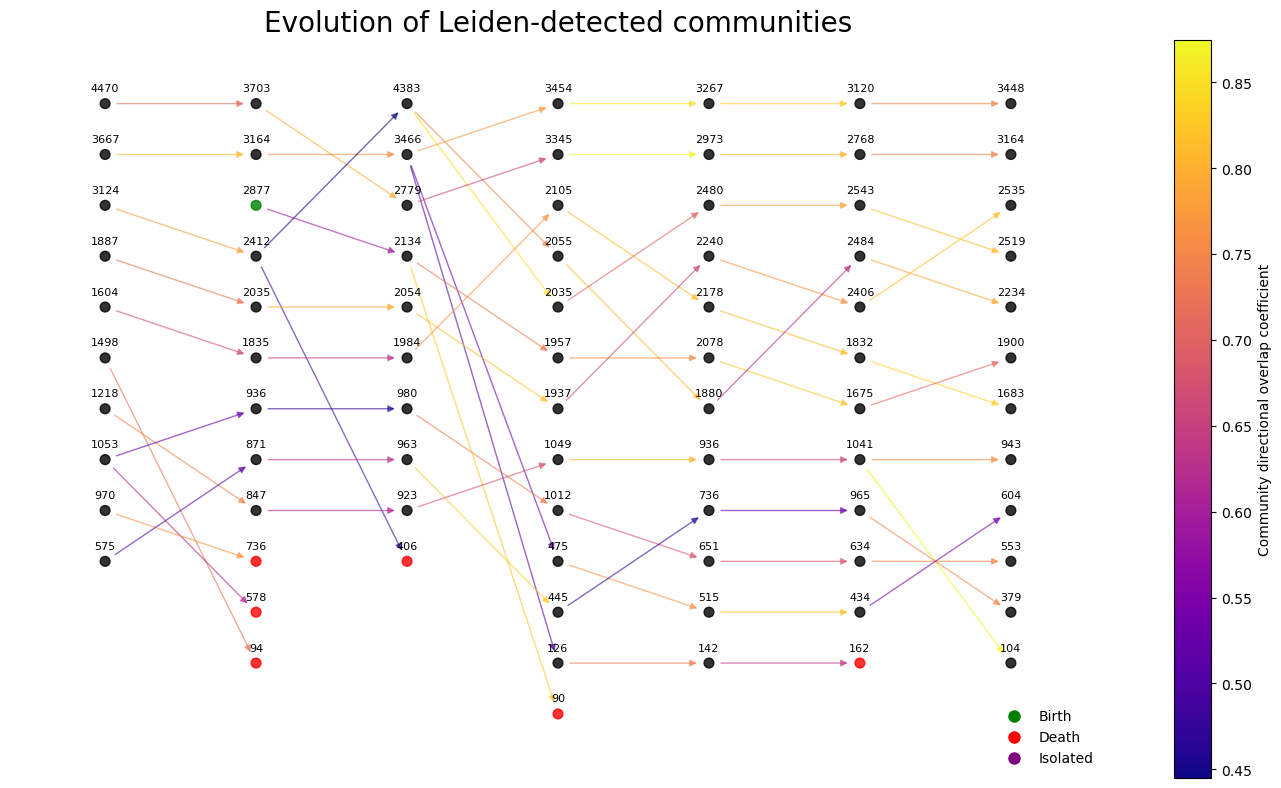

In [8]:
plot_temporal_community_similarity(sim_matrices, community_sizes, threshold=0.4)

#### Frequencies Entropy

In [9]:
import numpy as np

def compute_global_log_bins(all_freqs, n_bins=15, xmin=None):
    """
    all_freqs: iterable of arrays from ALL snapshots
    n_bins: number of bins in log space
    xmin: optional lower cutoff (if distribution is truncated)
    """
    data = np.concatenate(all_freqs).astype(float)
    data = data[data > 0]

    if xmin is not None:
        data = data[data >= xmin]

    if len(data) == 0:
        raise ValueError("No valid data after filtering.")

    log_min = np.log(data.min())
    log_max = np.log(data.max())

    # Equal-width bins in log space
    edges = np.exp(np.linspace(log_min, log_max, n_bins + 1))

    return edges

In [10]:
def bin_frequencies(freqs, bin_edges):
    """
    Returns histogram counts using fixed global bin edges.
    """
    freqs = np.asarray(freqs, dtype=float)
    freqs = freqs[freqs > 0]

    hist, _ = np.histogram(freqs, bins=bin_edges)
    return hist

In [11]:
# import numpy as np

# def community_freq_stats(freqs):
#     freqs = np.asarray(freqs, dtype=float)

#     n = len(freqs)

#     if n == 0:
#         return {
#             "entropy_norm": 0.0,
#             "n_eff": 0.0
#         }

#     if n == 1:
#         return {
#             "entropy_norm": 0.0,
#             "n_eff": 1.0
#         }

#     p = freqs / freqs.sum()

#     entropy = -np.sum(p * np.log(p))
#     entropy_norm = entropy / np.log(n)
#     n_eff = np.exp(entropy)

#     return {
#         "entropy_norm": entropy_norm,
#         "n_eff": n_eff
#     }
import numpy as np

def community_freq_stats(freqs, bin_edges):
    """
    freqs: raw frequency values
    bin_edges: global bin edges computed once
    """

    freqs = np.asarray(freqs, dtype=float)
    freqs = freqs[freqs > 0]

    if len(freqs) == 0:
        return {
            "entropy_norm": 0.0,
            "n_eff": 0.0
        }

    # ---- GLOBAL BINNING ----
    hist, _ = np.histogram(freqs, bins=bin_edges)

    # Total number of bins is fixed
    n_bins = len(hist)

    if hist.sum() == 0:
        return {
            "entropy_norm": 0.0,
            "n_eff": 0.0
        }

    p = hist / hist.sum()

    # Avoid log(0) safely
    p_nonzero = p[p > 0]

    entropy = -np.sum(p_nonzero * np.log(p_nonzero))

    # Normalize by fixed bin count
    entropy_norm = entropy / np.log(n_bins)

    n_eff = np.exp(entropy)

    return {
        "entropy_norm": entropy_norm,
        "n_eff": n_eff
    }

In [12]:
import numpy as np
import os
import json
import igraph as ig

# ---- Collect all frequencies globally ----
all_freqs = []

for i in range(1, 8):
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    freqs = [v["freq"] for v in g.vs if v["freq"] > 0]
    all_freqs.append(np.array(freqs))

# Compute global log bins
bin_edges = compute_global_log_bins(all_freqs, n_bins=15, xmin=None)

stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["freq"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]

        if len(freqs) == 0:
            continue

        s = community_freq_stats(freqs, bin_edges)

        snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [13]:
# stats = []

# for i in range(1, 8):
#     print(f"Snapshot {i}")

#     # load clustering
#     file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
#     with open(file, "r", encoding="utf-8") as f:
#         part = json.load(f)

#     # load graph
#     file = os.path.join("networks_core", f"graph_snap{i}.igp")
#     g = ig.Graph.Read_Pickle(file)

#     # token -> frequency
#     words_freqs = {v["token"]: v["freq"] for v in g.vs}

#     snapshot_stats = []

#     for com in part:
#         freqs = [words_freqs[word] for word in com if word in words_freqs]
#         s = community_freq_stats(freqs)

#         if s is not None:
#             snapshot_stats.append(s)

#     stats.append(snapshot_stats)

In [14]:
def print_table(stats):
    summary = []

    for snap_stats in stats:
        ent = np.array([c["entropy_norm"] for c in snap_stats])
        neff = np.array([c["n_eff"] for c in snap_stats])

        summary.append({
            "entropy_mean": ent.mean(),
            "entropy_median": np.median(ent),
            "neff_mean": neff.mean(),
            "neff_median": np.median(neff)
        })

    from tabulate import tabulate

    rows = []
    for i, row in enumerate(summary, start=1):
        rows.append([
            i,
            row["entropy_mean"],
            row["entropy_median"],
            row["neff_mean"],
            row["neff_median"]
        ])

    print(tabulate(
        rows,
        headers=["Snapshot", "Entropy (mean)", "Entropy (median)", "N_eff (mean)", "N_eff (median)"],
        floatfmt=".3f"
    ))

In [15]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.722               0.715           7.126             6.941
         2             0.721               0.710           7.137             6.853
         3             0.721               0.721           7.114             7.047
         4             0.708               0.696           6.871             6.586
         5             0.719               0.697           7.045             6.610
         6             0.729               0.712           7.255             6.878
         7             0.730               0.705           7.272             6.748


### Bridges

In [39]:
def bridges_from_clustering(graph: ig.Graph, clustering: list, weight_attr="weight"):
    """
    Identify bridges (cross-community edges) for a snapshot clustering, fast version.
    
    Avoids betweenness computation. Returns bridge edges with weight and nodes.
    
    Parameters:
        graph (igraph.Graph): undirected igraph.Graph with 'name' attribute for nodes
        clustering (list of lists): each inner list is a community of node labels
        weight_attr (str): name of edge weight attribute; defaults to 'weight'
    
    Returns:
        list of dicts: each dict has:
            - 'edge_index': igraph edge index
            - 'nodes': [(source_index, source_label), (target_index, target_label)]
            - 'weight': edge weight (or 1 if not weighted)
            - 'community_pair': tuple of (community_u, community_v)
    """
    # Build label -> community map
    node_to_community = {}
    for cid, comm in enumerate(clustering):
        for node_label in comm:
            node_to_community[node_label] = cid

    bridges = []
    
    for e in graph.es:
        u_idx, v_idx = e.tuple
        u_label = graph.vs[u_idx]['token']
        v_label = graph.vs[v_idx]['token']
        cid_u = node_to_community[u_label]
        cid_v = node_to_community[v_label]
        u_freq = graph.vs[u_idx]['freq']
        v_freq = graph.vs[v_idx]['freq']
        
        u_dm = graph.vs[u_idx]['demauro_level']
        v_dm = graph.vs[v_idx]['demauro_level']
        
        t_edge = 'mixed'
        if u_dm != 3 and v_dm != 3:
            t_edge = 'both_vdb'
        elif u_dm == 3 and v_dm == 3:
            t_edge = 'both_nvdb'

        if cid_u != cid_v:
            bridges.append({
                'edge_index': e.index,
                'nodes': [(u_idx, u_label), (v_idx, v_label)],
                'weight': e[weight_attr] if weight_attr in graph.es.attribute_names() else 1,
                'community_pair': (cid_u, cid_v),
                'mean_freq': (u_freq + v_freq) / 2,
                'type': t_edge
            })

    return bridges

In [51]:
tot_freq_global = list()
tot_freq_vdb_global = list()
tot_freq_mixed_global = list()
tot_freq_nvdb_global = list()

for i in range(1, 8):
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)
    
    # g is your igraph.Graph with nodes labeled in 'name'
    # clustering is a list of lists of labels

    bridges = bridges_from_clustering(g, part, weight_attr='weight')

    print(f'Snap {i}:')

    tot_freq = list()
    tot_freq_vdb = list()
    tot_freq_nvdb = list()
    tot_freq_mixed = list()

    # Inspect top 5 bridges
    for b in bridges:
        tot_freq.append(b['mean_freq'])
        if b['type'] == 'both_vdb':
            tot_freq_vdb.append(b['mean_freq'])
        elif b['type'] == 'both_nvdb':
            tot_freq_nvdb.append(b['mean_freq'])
        elif b['type'] == 'mixed':
            tot_freq_mixed.append(b['mean_freq'])
        
    
    print(f'\t#bridges: {len(tot_freq)}')
    print(f'\tMean Frequency: {np.mean(tot_freq)}')
    print(f'\tMedian Frequency: {np.median(tot_freq)}')
    tot_freq_global.append(tot_freq)

    print(f'\t#both VdB: {len(tot_freq_vdb)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_vdb)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_vdb)}')
    tot_freq_vdb_global.append(tot_freq_vdb)
    
    print(f'\t#mixed: {len(tot_freq_mixed)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_mixed)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_mixed)}')
    tot_freq_mixed_global.append(tot_freq_mixed)
    
    print(f'\t#both nVdB: {len(tot_freq_nvdb)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_nvdb)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_nvdb)}')
    tot_freq_nvdb_global.append(tot_freq_nvdb)

Snap 1:
	#bridges: 220660
	Mean Frequency: 1028.7482620320854
	Median Frequency: 210.5
	#both VdB: 17332
		Mean Frequency: 3319.6433764135704
		Median Frequency: 686.0
	#mixed: 75332
		Mean Frequency: 1795.727844740615
		Median Frequency: 362.0
	#both nVdB: 127996
		Mean Frequency: 267.1314923903872
		Median Frequency: 161.5
Snap 2:
	#bridges: 281812
	Mean Frequency: 1146.2890366627396
	Median Frequency: 214.0
	#both VdB: 28938
		Mean Frequency: 3458.8180074642337
		Median Frequency: 698.0
	#mixed: 105944
		Mean Frequency: 1722.8844814241486
		Median Frequency: 371.5
	#both nVdB: 146930
		Mean Frequency: 275.07967739740013
		Median Frequency: 148.5
Snap 3:
	#bridges: 235205
	Mean Frequency: 1257.1615824493526
	Median Frequency: 235.0
	#both VdB: 23571
		Mean Frequency: 4301.463959950787
		Median Frequency: 924.0
	#mixed: 87842
		Mean Frequency: 1833.9563136085244
		Median Frequency: 431.5
	#both nVdB: 123792
		Mean Frequency: 268.21194018999614
		Median Frequency: 159.5
Snap 4:
	#bridg

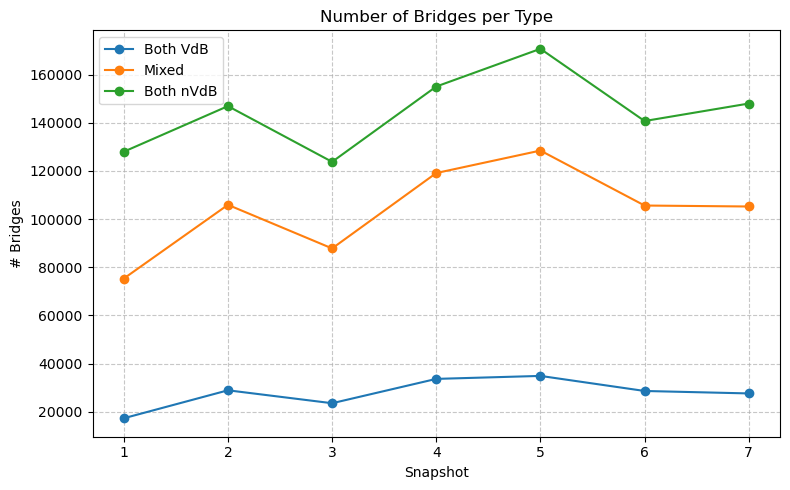

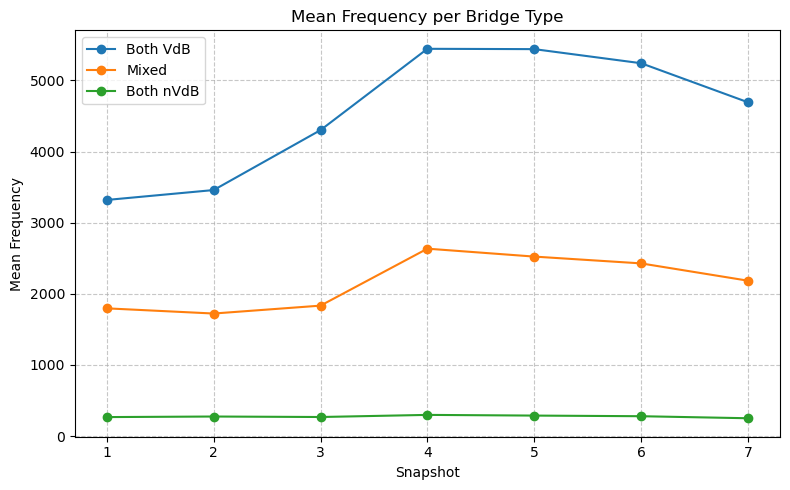

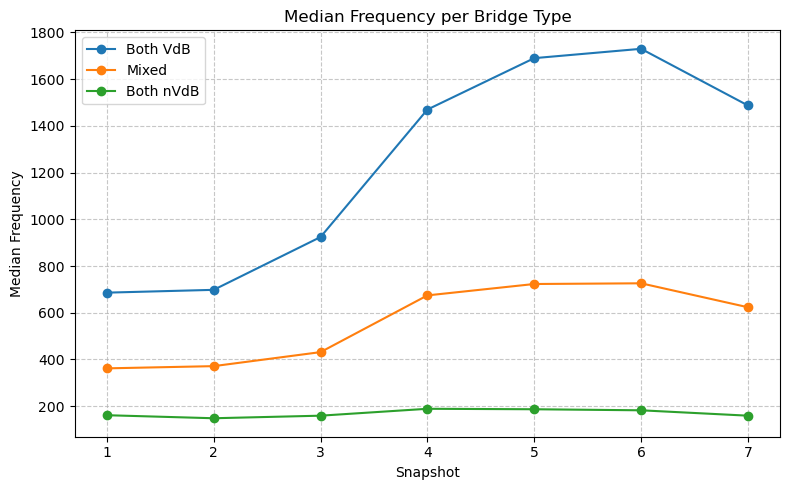

In [52]:
import matplotlib.pyplot as plt
import numpy as np

snapshots = list(range(1, 8))  # snapshot indices

# -----------------------------
# 1. Number of bridges per type
num_bridges_vdb = [len(f) for f in tot_freq_vdb_global]
num_bridges_mixed = [len(f) for f in tot_freq_mixed_global]
num_bridges_nvdb = [len(f) for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, num_bridges_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, num_bridges_mixed, marker='o', label='Mixed')
plt.plot(snapshots, num_bridges_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("# Bridges")
plt.title("Number of Bridges per Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Mean Frequency per type
mean_vdb = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_vdb_global]
mean_mixed = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_mixed_global]
mean_nvdb = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, mean_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, mean_mixed, marker='o', label='Mixed')
plt.plot(snapshots, mean_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("Mean Frequency")
plt.title("Mean Frequency per Bridge Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Median Frequency per type
median_vdb = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_vdb_global]
median_mixed = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_mixed_global]
median_nvdb = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, median_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, median_mixed, marker='o', label='Mixed')
plt.plot(snapshots, median_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("Median Frequency")
plt.title("Median Frequency per Bridge Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

/Users/brunobarbieri/miniforge3/envs/acn_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


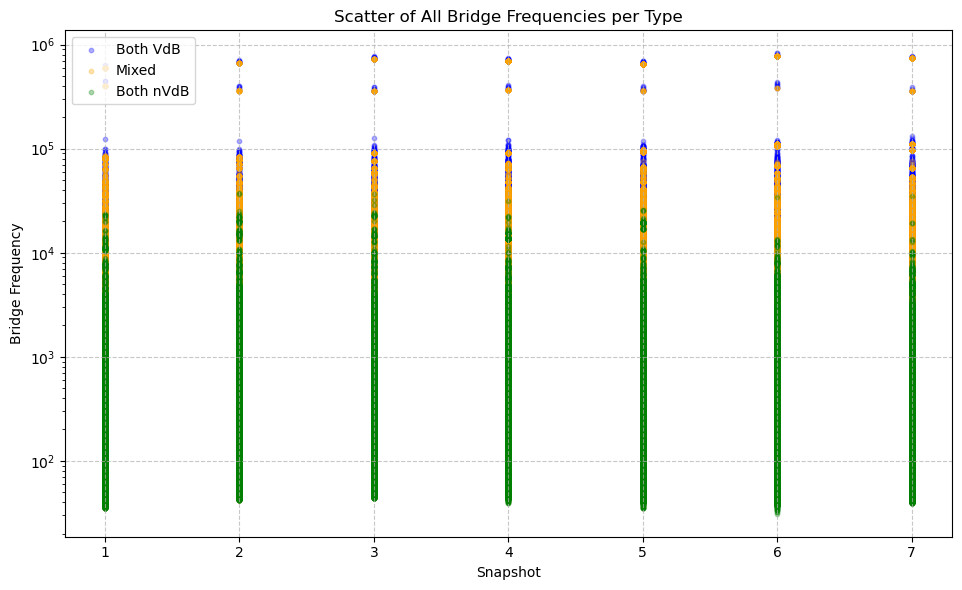

In [54]:
import matplotlib.pyplot as plt
import numpy as np

snapshots = np.array(range(1, 8))  # snapshot indices

# -----------------------------
# 1. Scatter of all frequencies per type
plt.figure(figsize=(10,6))

for i, snap in enumerate(snapshots):
    # Each list contains frequencies for all bridges of that type in this snapshot
    freqs_vdb = tot_freq_vdb_global[i]
    freqs_mixed = tot_freq_mixed_global[i]
    freqs_nvdb = tot_freq_nvdb_global[i]
    
    # Plot all individual points for this snapshot
    plt.scatter([snap]*len(freqs_vdb), freqs_vdb, color='blue', alpha=0.3, label='Both VdB' if i==0 else "", s=10)
    plt.scatter([snap]*len(freqs_mixed), freqs_mixed, color='orange', alpha=0.3, label='Mixed' if i==0 else "", s=10)
    plt.scatter([snap]*len(freqs_nvdb), freqs_nvdb, color='green', alpha=0.3, label='Both nVdB' if i==0 else "", s=10)

plt.xlabel("Snapshot")
plt.ylabel("Bridge Frequency")
plt.title("Scatter of All Bridge Frequencies per Type")
plt.legend()
plt.grid(True, alpha= 0.7, linestyle='--')
plt.tight_layout()
plt.yscale('log')
plt.show()

##### Demauro Entropy

In [61]:
import numpy as np
from collections import Counter

def demauro_entropy_stats(demauro_list):
    """
    Computes normalized entropy and effective number of categories (n_eff)
    for a list of Demauro coefficients (categorical labels).

    Parameters
    ----------
    demauro_list : list of int
        Categorical labels (e.g., 0,1,2 = basic, 3 = complex).

    Returns
    -------
    dict
        {
            "entropy_norm": float,  # normalized entropy (0-1)
            "n_eff": float          # effective number of categories
        }
    """
    # Count occurrences of each category
    freqs = np.array(list(Counter(demauro_list).values()), dtype=float)
    
    n = len(freqs)
    
    # Handle degenerate cases
    if n == 0:
        return {"entropy_norm": 0.0, "n_eff": 0.0}
    if n == 1:
        return {"entropy_norm": 0.0, "n_eff": 1.0}

    # Probabilities
    p = freqs / freqs.sum()
    
    # Shannon entropy
    entropy = -np.sum(p * np.log(p))
    
    # Normalized entropy
    entropy_norm = entropy / np.log(n)
    
    # Effective number of categories
    n_eff = np.exp(entropy)
    
    return {
        "entropy_norm": entropy_norm,
        "n_eff": n_eff
    }

##### 0, 1, 2, 3

In [62]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["demauro_level"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [63]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.574               0.626           2.274             2.382
         2             0.588               0.638           2.327             2.421
         3             0.604               0.643           2.361             2.439
         4             0.616               0.656           2.398             2.484
         5             0.633               0.677           2.462             2.558
         6             0.634               0.674           2.466             2.545
         7             0.610               0.648           2.382             2.456


In [64]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: (1 if v["demauro_level"] == 3 else 0) for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


##### (0, 1, 2) vs 3

In [65]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.780               0.860           1.731             1.815
         2             0.791               0.867           1.745             1.824
         3             0.817               0.879           1.774             1.839
         4             0.828               0.905           1.785             1.872
         5             0.840               0.919           1.803             1.891
         6             0.841               0.912           1.804             1.882
         7             0.821               0.889           1.779             1.851


#### Cohesion and Connectivity

In [66]:
def community_structure_stats(g, community_tokens):
    # map tokens to vertex indices
    token_to_vid = {v["token"]: v.index for v in g.vs}
    vids = [token_to_vid[w] for w in community_tokens if w in token_to_vid]

    n = len(vids)
    if n < 2:
        return None

    sub = g.subgraph(vids)

    m = sub.ecount()
    possible = n * (n - 1) / 2

    connectivity = m / possible if possible > 0 else 0.0

    if m > 0:
        cohesion = sum(sub.es["weight"]) / m
    else:
        cohesion = 0.0

    return {
        "n_nodes": n,
        "n_edges": m,
        "connectivity": connectivity,
        "cohesion": cohesion
    }

In [67]:
import os
import igraph as ig
import json


stats = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join('networks_core', f'graph_snap{i}.igp')
    g = ig.Graph.Read_Pickle(file)
    
    stats.append(list())
    
    for com in part:
        stats[-1].append(community_structure_stats(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [68]:
import numpy as np

def print_structural_snapshot_table(stats):
    """
    Print per-snapshot aggregates for community structure stats.
    Works even if only connectivity/cohesion/n_nodes/n_edges are present.
    Shows both mean and median.
    """
    print("\nSnapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)")
    print("-" * 127)

    for snap, snap_stats in enumerate(stats, start=1):
        if not snap_stats:
            continue

        sizes = np.array([c["n_nodes"] for c in snap_stats])
        edges = np.array([c["n_edges"] for c in snap_stats])
        conn = np.array([c["connectivity"] for c in snap_stats])
        coh = np.array([c["cohesion"] for c in snap_stats])

        # Weighted cohesion by community size
        coh_w = np.average(coh, weights=sizes)

        print(
            f"{snap:8} |"
            f"{len(snap_stats):5} |"
            f"{sizes.mean():12.1f} | {np.median(sizes):10.1f} |"
            f"{edges.mean():12.0f} | {np.median(edges):10.0f} |"
            f"{conn.mean():10.3f} | {np.median(conn):8.3f} |"
            f"{coh.mean():9.3f} | {np.median(coh):7.3f} |"
            f"{coh_w:12.3f}"
        )


In [69]:
print_structural_snapshot_table(stats)


Snapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)
-------------------------------------------------------------------------------------------------------------------------------
       1 |   10 |      2006.6 |     1551.0 |       73526 |      55792 |     0.044 |    0.037 |    0.677 |   0.671 |       0.673
       2 |   12 |      1674.0 |     1385.5 |       62317 |      60085 |     0.063 |    0.047 |    0.612 |   0.608 |       0.607
       3 |   10 |      2007.2 |     2019.0 |       71284 |      59584 |     0.039 |    0.039 |    0.612 |   0.606 |       0.606
       4 |   13 |      1545.0 |     1937.0 |       55080 |      42169 |     0.092 |    0.049 |    0.616 |   0.607 |       0.609
       5 |   12 |      1673.0 |     1979.0 |       60200 |      61523 |     0.064 |    0.039 |    0.613 |   0.605 |       0.607
       6 |   12 |      1672.0 |     1753.5 |       54885 |      44114 |     0.060 |    0.039 |    0.613

In [70]:
stats

[[{'n_nodes': 4470,
   'n_edges': 143656,
   'connectivity': 0.014382549834980525,
   'cohesion': 0.6695033568524725},
  {'n_nodes': 3667,
   'n_edges': 107616,
   'connectivity': 0.01601044749539954,
   'cohesion': 0.6674510466473409},
  {'n_nodes': 3124,
   'n_edges': 109973,
   'connectivity': 0.022544108126768353,
   'cohesion': 0.6661945667391086},
  {'n_nodes': 1887,
   'n_edges': 182708,
   'connectivity': 0.10267718907229854,
   'cohesion': 0.667191958359794},
  {'n_nodes': 1604,
   'n_edges': 66655,
   'connectivity': 0.05184714445950003,
   'cohesion': 0.6725931072837692},
  {'n_nodes': 1498,
   'n_edges': 36337,
   'connectivity': 0.03240749411595777,
   'cohesion': 0.6770630027245015},
  {'n_nodes': 1218,
   'n_edges': 14474,
   'connectivity': 0.019529031117731428,
   'cohesion': 0.7127130985214886},
  {'n_nodes': 1053,
   'n_edges': 44928,
   'connectivity': 0.08111533586818757,
   'cohesion': 0.6924342216880321},
  {'n_nodes': 970,
   'n_edges': 19745,
   'connectivity':

#### Community understanding

In [71]:
import heapq

def topk_central_nodes_eigen(g, community, k=3, weight_attr="weight"):
    """
    Returns a list of (token, eigenvector_centrality),
    sorted from highest to lowest.
    """
    subg = g.induced_subgraph(
        g.vs.select(token_in=community)
    )

    eig = subg.eigenvector_centrality(
        weights=subg.es[weight_attr],
        scale=False
    )

    k = min(k, len(eig))

    topk_idx = heapq.nlargest(
        k,
        range(len(eig)),
        key=eig.__getitem__
    )

    return [
        (subg.vs[i]["token"], eig[i])
        for i in topk_idx
    ]

In [72]:
centroids = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("leiden_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    centroids.append(list())
    
    for com in part:
        centroids[-1].append(topk_central_nodes_eigen(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [73]:
centroids

[[[('politicizzazione', 1.0),
   ('diversificazione', 0.9603443532456795),
   ('strumentalizzazione', 0.945535018711336)],
  [('scaraventare', 0.9999999999999999),
   ('pianerottolo', 0.9644781010513241),
   ('sdraiare', 0.9127036288982652)],
  [('evidentemente', 1.0),
   ('naturalmente', 0.9290877974919814),
   ('invece', 0.7177859997047997)],
  [('baldassarre', 1.0),
   ('giampaolo', 0.9892852354028662),
   ('beccatello', 0.984445283308805)],
  [('feeling', 1.0),
   ('watson', 0.9272557581811387),
   ('marker', 0.9180736322299172)],
  [('coreografia', 0.9999999999999999),
   ('satirico', 0.942178640111426),
   ('neorealismo', 0.9038199292066856)],
  [('settanta', 1.0),
   ('quaranta', 0.994604942028277),
   ('trentacinque', 0.9885626973134838)],
  [('novarare', 1.0),
   ('perugio', 0.9845238870521282),
   ('arezzo', 0.9656678091596935)],
  [('are', 1.0), ('teo', 0.9987485636195821), ('cna', 0.9932013355486288)],
  [('seviziare', 1.0),
   ('efferato', 0.9823197389591044),
   ('sevizia

## Infomap communities comparison by snapshot

In [91]:
sim_matrices = list()
community_sizes = list()

for i in range(1, 8):
    file = os.path.join('infomap_clusterings', f'clust_snap{i}.json')
    if i > 1:
        part_prev = part_cur
    with open(file, 'r', encoding='utf-8') as f:
        part_cur = json.load(f)
    
    community_sizes.append(list())
    
    for com in part_cur:
        community_sizes[-1].append(len(com))
    
    if i == 1:
        continue
    
    matrix = compare_partitions(part_prev=part_prev, part_cur=part_cur)
    sim_matrices.append(matrix)
    
    print(f'\nSnapshot {i} w.r.t. snapshot {i-1} (shape: {matrix.shape}):')
    for j, row in enumerate(matrix):
        print(f'\tCommunity {j}:')
        print(f'\t\tmax JS: {np.max(row)}')
        print(f'\t\tmax JS: {np.argmax(row)}')


Snapshot 2 w.r.t. snapshot 1 (shape: (131, 212)):
	Community 0:
		max JS: 0.5302166476624858
		max JS: 0
	Community 1:
		max JS: 0.676343421865349
		max JS: 12
	Community 2:
		max JS: 0.384917517674784
		max JS: 27
	Community 3:
		max JS: 0.6948249619482496
		max JS: 3
	Community 4:
		max JS: 0.4595375722543353
		max JS: 39
	Community 5:
		max JS: 0.628
		max JS: 7
	Community 6:
		max JS: 0.6181046676096181
		max JS: 8
	Community 7:
		max JS: 0.38341463414634147
		max JS: 3
	Community 8:
		max JS: 0.40540540540540543
		max JS: 29
	Community 9:
		max JS: 0.7272727272727273
		max JS: 17
	Community 10:
		max JS: 0.5957446808510638
		max JS: 12
	Community 11:
		max JS: 0.6
		max JS: 3
	Community 12:
		max JS: 0.36363636363636365
		max JS: 3
	Community 13:
		max JS: 0.25396825396825395
		max JS: 14
	Community 14:
		max JS: 0.7253218884120172
		max JS: 11
	Community 15:
		max JS: 0.45933014354066987
		max JS: 5
	Community 16:
		max JS: 0.4696969696969697
		max JS: 1
	Community 17:
		max JS:


Snapshot | Total | Total>50 | Internal | Births | Deaths | Isolated | Merges | Splits
-------------------------------------------------------------------------------------
       0 |   212 |       43 |       23 |      0 |      0 |       20 |      0 |      3
       1 |   131 |       44 |       22 |      9 |     11 |        2 |      0 |      7
       2 |   136 |       49 |       24 |      4 |     16 |        5 |      0 |      4
       3 |   110 |       49 |       29 |      9 |      4 |        7 |      0 |      3
       4 |   114 |       41 |       29 |      1 |     11 |        0 |      1 |      5
       5 |   136 |       42 |       29 |      2 |      7 |        4 |      0 |      5
       6 |   137 |       45 |       36 |      0 |      0 |        9 |      0 |      0


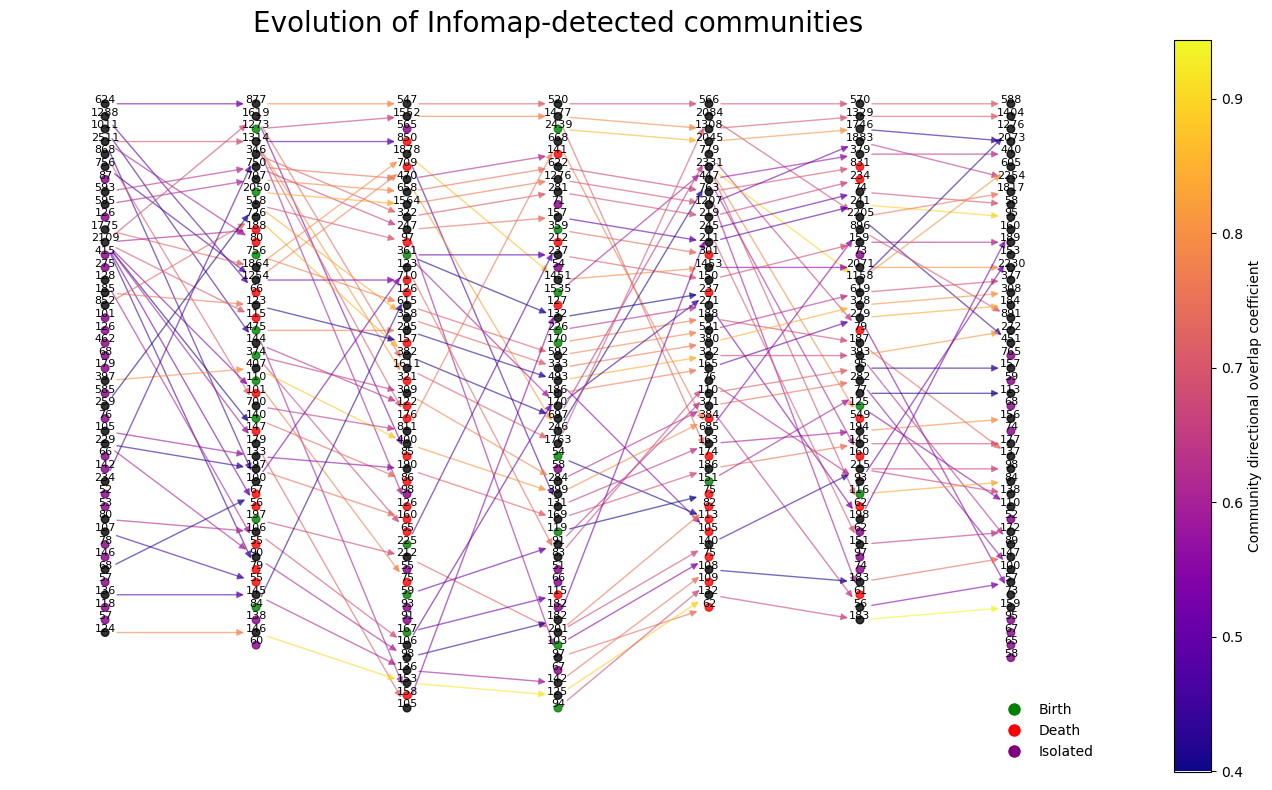

In [92]:
plot_temporal_community_similarity(sim_matrices, community_sizes, node_size=30, clustering='Infomap', threshold=0.4)

#### Frequencies Entropy

In [76]:
import numpy as np
import os
import json
import igraph as ig

# ---- Collect all frequencies globally ----
all_freqs = []

for i in range(1, 8):
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    freqs = [v["freq"] for v in g.vs if v["freq"] > 0]
    all_freqs.append(np.array(freqs))

# Compute global log bins
bin_edges = compute_global_log_bins(all_freqs, n_bins=15, xmin=None)

stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["freq"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]

        if len(freqs) == 0:
            continue

        s = community_freq_stats(freqs, bin_edges)

        snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [77]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.538               0.572           4.835             4.711
         2             0.567               0.632           5.280             5.532
         3             0.587               0.644           5.474             5.714
         4             0.575               0.649           5.261             5.803
         5             0.527               0.574           4.751             4.736
         6             0.569               0.639           5.263             5.650
         7             0.555               0.641           5.214             5.670


### Bridges

In [55]:
tot_freq_global = list()
tot_freq_vdb_global = list()
tot_freq_mixed_global = list()
tot_freq_nvdb_global = list()

for i in range(1, 8):
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)
    
    # g is your igraph.Graph with nodes labeled in 'name'
    # clustering is a list of lists of labels

    bridges = bridges_from_clustering(g, part, weight_attr='weight')

    print(f'Snap {i}:')

    tot_freq = list()
    tot_freq_vdb = list()
    tot_freq_nvdb = list()
    tot_freq_mixed = list()

    # Inspect top 5 bridges
    for b in bridges:
        tot_freq.append(b['mean_freq'])
        if b['type'] == 'both_vdb':
            tot_freq_vdb.append(b['mean_freq'])
        elif b['type'] == 'both_nvdb':
            tot_freq_nvdb.append(b['mean_freq'])
        elif b['type'] == 'mixed':
            tot_freq_mixed.append(b['mean_freq'])
        
    
    print(f'\t#bridges: {len(tot_freq)}')
    print(f'\tMean Frequency: {np.mean(tot_freq)}')
    print(f'\tMedian Frequency: {np.median(tot_freq)}')
    tot_freq_global.append(tot_freq)

    print(f'\t#both VdB: {len(tot_freq_vdb)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_vdb)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_vdb)}')
    tot_freq_vdb_global.append(tot_freq_vdb)
    
    print(f'\t#mixed: {len(tot_freq_mixed)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_mixed)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_mixed)}')
    tot_freq_mixed_global.append(tot_freq_mixed)
    
    print(f'\t#both nVdB: {len(tot_freq_nvdb)}')
    print(f'\t\tMean Frequency: {np.mean(tot_freq_nvdb)}')
    print(f'\t\tMedian Frequency: {np.median(tot_freq_nvdb)}')
    tot_freq_nvdb_global.append(tot_freq_nvdb)

Snap 1:
	#bridges: 299200
	Mean Frequency: 1441.3831667780748
	Median Frequency: 231.5
	#both VdB: 27392
		Mean Frequency: 5071.838328709112
		Median Frequency: 832.0
	#mixed: 105164
		Mean Frequency: 2313.416021642387
		Median Frequency: 412.5
	#both nVdB: 166644
		Mean Frequency: 294.3158199515134
		Median Frequency: 168.0
Snap 2:
	#bridges: 361964
	Mean Frequency: 1216.8644547524063
	Median Frequency: 220.0
	#both VdB: 39185
		Mean Frequency: 3579.2743269108078
		Median Frequency: 719.0
	#mixed: 137012
		Mean Frequency: 1812.188746241205
		Median Frequency: 379.0
	#both nVdB: 185767
		Mean Frequency: 279.4665171962728
		Median Frequency: 150.0
Snap 3:
	#bridges: 353370
	Mean Frequency: 1908.0085604324079
	Median Frequency: 273.0
	#both VdB: 40507
		Mean Frequency: 6614.56005134915
		Median Frequency: 1189.0
	#mixed: 134941
		Mean Frequency: 2626.5037460816206
		Median Frequency: 548.5
	#both nVdB: 177922
		Mean Frequency: 291.5544957902901
		Median Frequency: 170.5
Snap 4:
	#bridges

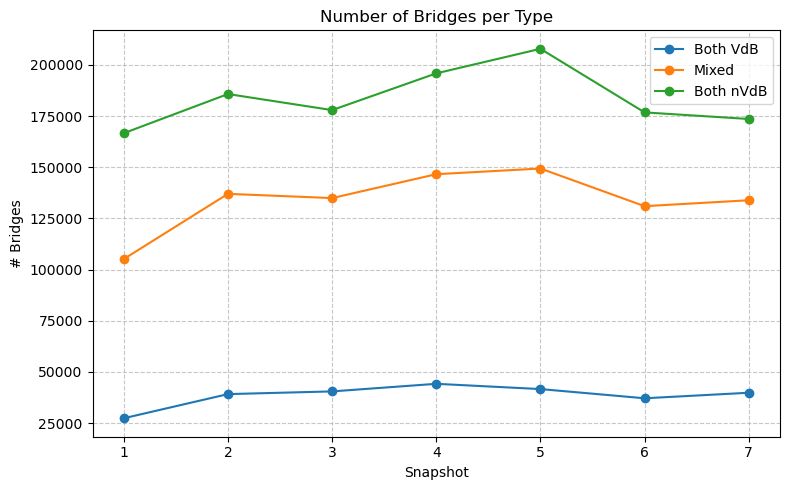

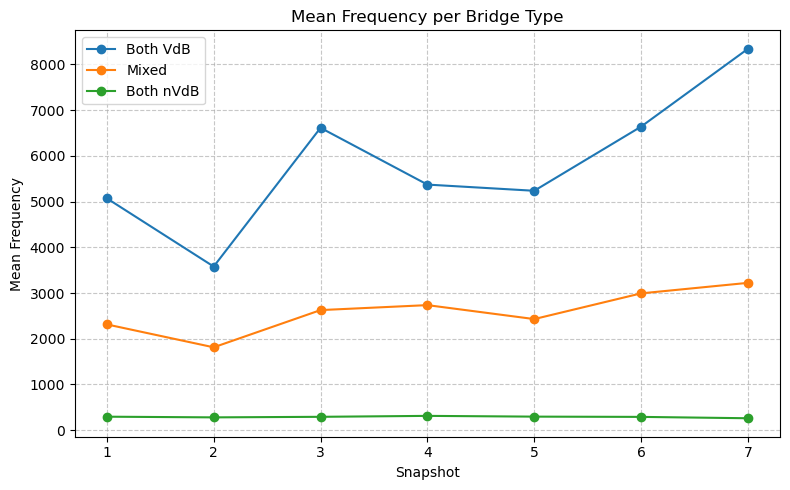

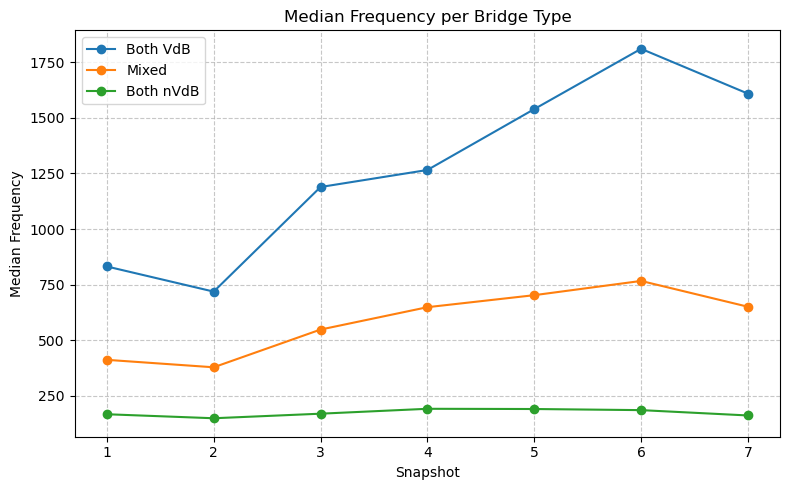

In [56]:
import matplotlib.pyplot as plt
import numpy as np

snapshots = list(range(1, 8))  # snapshot indices

# -----------------------------
# 1. Number of bridges per type
num_bridges_vdb = [len(f) for f in tot_freq_vdb_global]
num_bridges_mixed = [len(f) for f in tot_freq_mixed_global]
num_bridges_nvdb = [len(f) for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, num_bridges_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, num_bridges_mixed, marker='o', label='Mixed')
plt.plot(snapshots, num_bridges_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("# Bridges")
plt.title("Number of Bridges per Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Mean Frequency per type
mean_vdb = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_vdb_global]
mean_mixed = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_mixed_global]
mean_nvdb = [np.mean(f) if len(f) > 0 else 0 for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, mean_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, mean_mixed, marker='o', label='Mixed')
plt.plot(snapshots, mean_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("Mean Frequency")
plt.title("Mean Frequency per Bridge Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Median Frequency per type
median_vdb = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_vdb_global]
median_mixed = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_mixed_global]
median_nvdb = [np.median(f) if len(f) > 0 else 0 for f in tot_freq_nvdb_global]

plt.figure(figsize=(8,5))
plt.plot(snapshots, median_vdb, marker='o', label='Both VdB')
plt.plot(snapshots, median_mixed, marker='o', label='Mixed')
plt.plot(snapshots, median_nvdb, marker='o', label='Both nVdB')
plt.xlabel("Snapshot")
plt.ylabel("Median Frequency")
plt.title("Median Frequency per Bridge Type")
plt.legend()
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()
plt.show()

##### Complexity Entropy

##### 0, 1, 2, 3

In [78]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]: v["demauro_level"] for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [79]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.671               0.763           2.183             2.216
         2             0.642               0.721           2.147             2.217
         3             0.664               0.717           2.214             2.256
         4             0.651               0.703           2.160             2.202
         5             0.635               0.703           2.080             2.000
         6             0.641               0.703           2.137             2.089
         7             0.605               0.709           2.126             2.185


##### (0, 1, 2) vs 3

In [80]:
stats = []

for i in range(1, 8):
    print(f"Snapshot {i}")

    # load clustering
    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    # load graph
    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)

    # token -> frequency
    words_freqs = {v["token"]:(1 if v["demauro_level"] == 3 else 0) for v in g.vs}

    snapshot_stats = []

    for com in part:
        freqs = [words_freqs[word] for word in com if word in words_freqs]
        s = demauro_entropy_stats(freqs)

        if s is not None:
            snapshot_stats.append(s)

    stats.append(snapshot_stats)

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [81]:
print_table(stats)

  Snapshot    Entropy (mean)    Entropy (median)    N_eff (mean)    N_eff (median)
----------  ----------------  ------------------  --------------  ----------------
         1             0.767               0.918           1.741             1.890
         2             0.742               0.903           1.715             1.871
         3             0.791               0.918           1.762             1.890
         4             0.759               0.876           1.722             1.836
         5             0.731               0.901           1.701             1.868
         6             0.750               0.884           1.718             1.845
         7             0.714               0.890           1.687             1.853


#### Cohesion and Connectivity

In [83]:
import os
import igraph as ig
import json


stats = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    stats.append(list())
    
    for com in part:
        stats[-1].append(community_structure_stats(g, com))

Snapshot 1
Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [84]:
print_structural_snapshot_table(stats)


Snapshot | #Com | nNodes_mean | nNodes_med | nEdges_mean | nEdges_med | Conn_mean | Conn_med | Coh_mean | Coh_med | Coh_mean(w)
-------------------------------------------------------------------------------------------------------------------------------
       1 |  212 |        94.7 |        9.0 |        3098 |         17 |     0.506 |    0.462 |    0.728 |   0.719 |       0.680
       2 |  131 |       153.3 |       14.0 |        5097 |         39 |     0.460 |    0.379 |    0.655 |   0.646 |       0.613
       3 |  136 |       147.6 |       25.5 |        4373 |         79 |     0.411 |    0.315 |    0.644 |   0.635 |       0.613
       4 |  110 |       182.6 |       24.0 |        5793 |         87 |     0.399 |    0.290 |    0.652 |   0.642 |       0.614
       5 |  114 |       176.1 |        8.0 |        5769 |         14 |     0.507 |    0.496 |    0.658 |   0.640 |       0.611
       6 |  136 |       147.5 |       14.0 |        4329 |         32 |     0.440 |    0.295 |    0.651

#### Community understanding

In [85]:
centroids = list()

for i in range(1, 8):
    print(f"Snapshot {i}")

    file = os.path.join("infomap_clusterings", f"clust_snap{i}.json")
    with open(file, "r", encoding="utf-8") as f:
        part = json.load(f)

    file = os.path.join("networks_core", f"graph_snap{i}.igp")
    g = ig.Graph.Read_Pickle(file)
    
    centroids.append(list())
    
    for com in part:
        centroids[-1].append(topk_central_nodes_eigen(g, com))

Snapshot 1


/var/folders/68/gjrvx3m51494g9gp2r93j3vh0000gn/T/ipykernel_25327/592221401.py:12: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  eig = subg.eigenvector_centrality(


Snapshot 2
Snapshot 3
Snapshot 4
Snapshot 5
Snapshot 6
Snapshot 7


In [86]:
centroids

[[[('biancorosso', 1.0),
   ('juventino', 0.9860200263230674),
   ('rossonero', 0.9755988458075082)],
  [('dimenticare', 1.0),
   ('credere', 0.9880554919002915),
   ('alludere', 0.9744016689761722)],
  [('incredulità', 1.0),
   ('stravagante', 0.9801797773231374),
   ('incomprensibile', 0.9052787434057417)],
  [('politicizzazione', 1.0),
   ('diversificazione', 0.9539118373236343),
   ('strumentalizzazione', 0.9475307778025582)],
  [('feeling', 1.0),
   ('watson', 0.9287128397588081),
   ('marker', 0.9242522897357688)],
  [('naturalmente', 0.9999999999999999),
   ('evidentemente', 0.9977334133143171),
   ('unicamente', 0.9690000853256238)],
  [('indetto', 1.0),
   ('indetta', 0.9900851378387933),
   ('indettare', 0.9869289226828993)],
  [('siriare', 1.0),
   ('indonesiano', 0.9691591312984259),
   ('sudanese', 0.939828208912243)],
  [('maggiorazione', 1.0),
   ('compenso', 0.8549120749844655),
   ('contribuzione', 0.8509603069401186)],
  [('discuttere', 1.0),
   ('discutere', 0.901188

# RQ2 modularity and vdb bridge

In [ ]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd
from scipy.stats import entropy

# --- FASE 1: Identificazione del Core (token presenti in TUTTI i 7 snap) ---
all_sets = []
for i in range(1, 8):
    path = f'networks_core_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g_temp = pickle.load(f)
        # Usiamo l'attributo 'token' come identificativo unico
        all_sets.append(set(g_temp.vs['token']))

# Intersezione: otteniamo solo i token che "sopravvivono" per tutto il tempo
core_tokens = set.intersection(*all_sets)
print(f"Dimensioni del Core: {len(core_tokens)} nodi")

# --- FASE 2: Analisi del Core ---
results = []

for i in range(1, 8):
    path = f'networks_core_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # Selezioniamo solo i nodi che appartengono al core
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # Rilevamento Comunità sul Core (Louvain pesato sulla cosine similarity)
    # Assumiamo che il peso sia nell'attributo 'weight' degli archi
    weights = g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None
    clusters = g_core.community_multilevel(weights=weights)
    g_core.vs['community'] = clusters.membership
    
    # Calcolo VdB (demauro_level != 3) nel Core
    vdb_nodes = [v for v in g_core.vs if v['demauro_level'] != 3]
    total_vdb_core = len(vdb_nodes)
    
    vdb_distribution = []
    community_purity = []
    
    for c_id in range(len(clusters)):
        nodes_in_comm = [v for v in g_core.vs if v['community'] == c_id]
        size = len(nodes_in_comm)
        
        if size == 0: continue
        
        # Conteggio VdB nella comunità specifica
        vdb_in_comm = [v for v in nodes_in_comm if v['demauro_level'] != 3]
        count_vdb = len(vdb_in_comm)
        
        vdb_distribution.append(count_vdb)
        community_purity.append(count_vdb / size)

    # Entropia di Shannon normalizzata (dispersione del VdB)
    probs = [count / total_vdb_core for count in vdb_distribution if count > 0]
    H_norm = entropy(probs) / np.log(len(clusters)) if len(clusters) > 1 else 0
    
    results.append({
        'snapshot': i,
        'entropy_vdb': H_norm,
        'avg_purity': np.mean(community_purity),
        'num_communities': len(clusters),
        'modularity': g_core.modularity(clusters.membership)
    })

df_core_final = pd.DataFrame(results)
print(df_core_final)

FileNotFoundError: [Errno 2] No such file or directory: 'networks_core_annotated/graph_snap1_hybrid.igp'

In [ ]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd

bridge_results = []

for i in range(1, 8):
    path = f'networks_core_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # Isoliamo il Core
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # Rilevamento comunità (stesso metodo dell'analisi modularità)
    clusters = g_core.community_multilevel(weights=g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None)
    g_core.vs['community'] = clusters.membership
    
    inter_community_edges_count = 0
    vdb_bridge_count = 0
    
    for e in g_core.es:
        source, target = e.tuple
        # Se l'arco collega due comunità diverse
        if g_core.vs[source]['community'] != g_core.vs[target]['community']:
            inter_community_edges_count += 1
            # Controlliamo se almeno uno dei due nodi è VdB (demauro_level != 3)
            if g_core.vs[source]['demauro_level'] != 3 or g_core.vs[target]['demauro_level'] != 3:
                vdb_bridge_count += 1
                
    bridge_ratio = vdb_bridge_count / inter_community_edges_count if inter_community_edges_count > 0 else 0
    
    bridge_results.append({
        'snapshot': i,
        'vdb_bridge_ratio': bridge_ratio,
        'modularity': g_core.modularity(clusters.membership)
    })

df_bridge = pd.DataFrame(bridge_results)
print(df_bridge)

   snapshot  vdb_bridge_ratio  modularity
0         1          0.419893    0.614956
1         2          0.472179    0.594417
2         3          0.474970    0.597178
3         4          0.500949    0.570830
4         5          0.484692    0.548079
5         6          0.500346    0.570611
6         7          0.478201    0.575838


L'analisi del core rivela che l'impoverimento linguistico non si manifesta come scomparsa di termini, ma come un deterioramento della connettività specifica. L'aumento del vdb_bridge_ratio (fino al 50%) dimostra che il vocabolario di base ha assunto un ruolo centrale nella mediazione tra domini semantici diversi, causando una parallela erosione della modularità della rete. Il linguaggio è diventato strutturalmente più povero perché i confini tra i concetti sono diventati meno definiti e più dipendenti da un set ristretto di termini iper-frequenti."

In [ ]:
import igraph as ig
import pickle
import numpy as np
import pandas as pd
import random

# --- FASE 1: DEFINIZIONE DEL CORE ---
# Dobbiamo trovare i token comuni a tutti i 7 snapshot prima di analizzarli
all_sets = []
print("Identificazione dei token nel Core...")
for i in range(1, 8):
    path = f'networks_core_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g_temp = pickle.load(f)
        all_sets.append(set(g_temp.vs['token']))

# Intersezione: prendiamo solo i nodi presenti ovunque
core_tokens = set.intersection(*all_sets)
print(f"Core identificato: {len(core_tokens)} nodi persistenti.")

# --- FASE 2: ANALISI CON NULL MODEL ---
bridge_results = []
N_PERMUTATIONS = 100 

for i in range(1, 8):
    path = f'networks_core_annotated/graph_snap{i}_hybrid.igp'
    with open(path, 'rb') as f:
        g = pickle.load(f)
    
    # 1. Isoliamo il Core (ora core_tokens esiste!)
    indices_to_keep = [v.index for v in g.vs if v['token'] in core_tokens]
    g_core = g.subgraph(indices_to_keep)
    
    # 2. Rilevamento comunità
    # Usiamo il peso (cosine similarity) se disponibile
    weights = g_core.es['weight'] if 'weight' in g_core.edge_attributes() else None
    clusters = g_core.community_multilevel(weights=weights)
    g_core.vs['community'] = clusters.membership
    
    # 3. Calcolo Bridge Ratio REALE
    inter_community_edges = [e for e in g_core.es if g_core.vs[e.source]['community'] != g_core.vs[e.target]['community']]
    total_inter = len(inter_community_edges)
    
    # Calcolo VdB reale (demauro_level != 3)
    vdb_bridge_count = sum(1 for e in inter_community_edges if g_core.vs[e.source]['demauro_level'] != 3 
                           or g_core.vs[e.target]['demauro_level'] != 3)
    
    real_ratio = vdb_bridge_count / total_inter if total_inter > 0 else 0
    
    # 4. NULL MODEL: Shuffling delle etichette De Mauro
    labels_pool = [v['demauro_level'] for v in g_core.vs]
    null_ratios = []
    
    for _ in range(N_PERMUTATIONS):
        shuffled_labels = random.sample(labels_pool, len(labels_pool))
        null_vdb_count = 0
        for e in inter_community_edges:
            if shuffled_labels[e.source] != 3 or shuffled_labels[e.target] != 3:
                null_vdb_count += 1
        null_ratios.append(null_vdb_count / total_inter if total_inter > 0 else 0)
    
    # 5. Statistiche e Z-Score
    mean_null = np.mean(null_ratios)
    std_null = np.std(null_ratios)
    z_score = (real_ratio - mean_null) / std_null if std_null > 0 else 0
    
    bridge_results.append({
        'snapshot': i,
        'vdb_bridge_ratio': real_ratio,
        'null_mean': mean_null,
        'null_std': std_null,
        'z_score': z_score,
        'modularity': g_core.modularity(clusters.membership)
    })
    print(f"Snap {i}: Real {real_ratio:.3f} | Null {mean_null:.3f} | Z-Score {z_score:.2f}")

df_bridge_null = pd.DataFrame(bridge_results)
print("\n--- RISULTATI FINALI ---")
print(df_bridge_null)

Identificazione dei token nel Core...
Core identificato: 20113 nodi persistenti.
Snap 1: Real 0.409 | Null 0.492 | Z-Score -13.34
Snap 2: Real 0.476 | Null 0.493 | Z-Score -2.53
Snap 3: Real 0.488 | Null 0.491 | Z-Score -0.48
Snap 4: Real 0.504 | Null 0.492 | Z-Score 2.13
Snap 5: Real 0.500 | Null 0.492 | Z-Score 1.31
Snap 6: Real 0.493 | Null 0.493 | Z-Score 0.05
Snap 7: Real 0.480 | Null 0.493 | Z-Score -2.47

--- RISULTATI FINALI ---
   snapshot  vdb_bridge_ratio  null_mean  null_std    z_score  modularity
0         1          0.409113   0.492021  0.006215 -13.340139    0.614063
1         2          0.475765   0.492538  0.006630  -2.529733    0.592046
2         3          0.488477   0.491186  0.005593  -0.484501    0.598005
3         4          0.504467   0.492162  0.005768   2.133398    0.564200
4         5          0.499845   0.492475  0.005646   1.305454    0.555670
5         6          0.492963   0.492721  0.004780   0.050669    0.573913
6         7          0.480138   0.493135 